In [212]:
import numpy as np
import matplotlib.pyplot as plt

from src.models.inner_product import InnerProduct

def generate_random_rbf(n_centers=5, sigma=1.0, weight_scale=1.0):
    """
    Generate a random 1-dimensional radial basis function with randomly chosen kernel type.

    Parameters:
    - n_centers: number of RBF centers
    - sigma: parameter controlling kernel spread
    - weight_scale: scale factor for random weights

    Returns:
    - A callable radial basis function f(x) accepting an array of points and returning an array of outputs
    """
    kernel_types = ['gaussian', 'inverse_quadratic', 'multiquadric']
    kernel = np.random.choice(kernel_types)

    centers = np.random.uniform(0, 1, size=n_centers)
    weights = np.random.randn(n_centers) * weight_scale

    def kernel_function(distances_sq):
        if kernel == 'gaussian':
            return np.exp(-distances_sq / (2 * sigma ** 2))
        elif kernel == 'inverse_quadratic':
            return 1 / (1 + distances_sq / sigma ** 2)
        elif kernel == 'multiquadric':
            return np.sqrt(1 + distances_sq / sigma ** 2)
        else:
            raise ValueError(f"Unknown kernel type: {kernel}")

    def rbf(x):
        x = np.atleast_1d(x)
        distances_sq = (x[:, np.newaxis] - centers[np.newaxis, :]) ** 2
        basis_vals = kernel_function(distances_sq)
        return basis_vals @ weights

    return rbf

# Example usage:
rbf_fn = generate_random_rbf(n_centers=10, sigma=0.2)

# Evaluate the function at multiple sample points
x = np.linspace(0, 1, 100)
y = rbf_fn(x)
print(len(y))
print(y)

100
[ 0.40049352  0.42151999  0.44314722  0.46521307  0.48750721  0.50976556
  0.53166618  0.55282736  0.5728089   0.59111752  0.60721732  0.62054565
  0.63053437  0.63663554  0.63834982  0.63525515  0.62703261  0.61348649
  0.59455611  0.57031787  0.54097749  0.50685369  0.46835575  0.42595792
  0.38017398  0.33153437  0.28056807  0.22779006  0.17369464  0.11875378
  0.06341968  0.00812976 -0.04668726 -0.10060581 -0.1531998  -0.20404162
 -0.25270449 -0.29876788 -0.34182535 -0.38149396 -0.41742382 -0.44930686
 -0.47688412 -0.49995148 -0.51836409 -0.53204023 -0.54096487 -0.54519326
 -0.54485379 -0.54014947 -0.53135675 -0.51882068 -0.50294616 -0.48418508
 -0.46302057 -0.43994907 -0.41546185 -0.39002688 -0.36407172 -0.3379679
 -0.31201645 -0.28643467 -0.26134365 -0.23675687 -0.2125703  -0.18855509
 -0.16435451 -0.139487   -0.11335746 -0.08527848 -0.05450256 -0.02026512
  0.01816325  0.06141856  0.10998373  0.16413272  0.22388397  0.28896809
  0.35881313  0.43254936  0.5090337   0.58689238

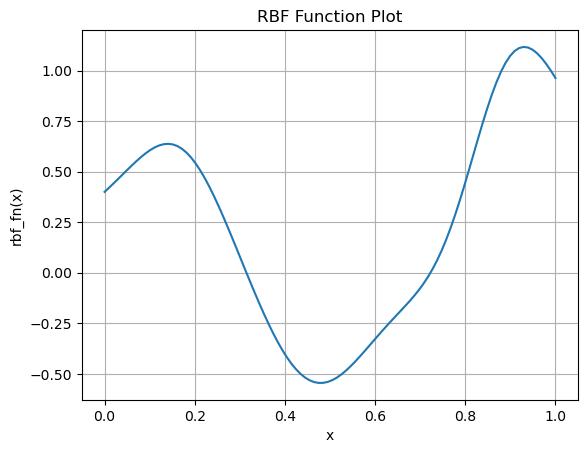

In [213]:
# Plot the results
plt.plot(x, y)
plt.title("RBF Function Plot")
plt.xlabel("x")
plt.ylabel("rbf_fn(x)")
plt.grid(True)
plt.show()

In [214]:
import torch

inner_product = InnerProduct(1000, 256)

tensor = torch.randn(128, 3, 1000)

output = inner_product(tensor)
print(output.size())

torch.Size([128, 1])


In [215]:
# Example tensor of shape (1000,)
tensor = torch.randn(1000)

# Example mask of shape (1000,) containing boolean values
mask = torch.rand(1000) > 0.7  # Example mask that retains ~30% of values

# Applying the mask to extract the relevant values (will have shape (~300,))
selected_values = tensor[mask]

print(selected_values.shape)  

torch.Size([302])


In [216]:
# BASIS = torch.randn(32, 100, 1000)
# X = torch.randn(32, 1000)

# batch_size, K, D = BASIS.shape  # BASIS is (batch_size, K, 1000)
# assert X.shape == (batch_size, D)

# # Expand X to match all pairs: (batch_size, K, K, D)
# X_expanded = X[:, None, None, :].expand(-1, K, K, -1)

# # Expand BASIS to form all possible pairs: (batch_size, K, K, D)
# BASIS_1 = BASIS[:, :, None, :].expand(-1, -1, K, -1)  # shape: (batch_size, K, K, D)
# BASIS_2 = BASIS[:, None, :, :].expand(-1, K, -1, -1)  # shape: (batch_size, K, K, D)

# # Stack to create input tensor for inner_product:
# # Resulting shape: (batch_size, K, K, 3, D)
# input_tensor = torch.stack([X_expanded, BASIS_1, BASIS_2], dim=3)

# # Reshape to merge first three dimensions into batch dimension for efficient computation:
# input_tensor = input_tensor.reshape(batch_size * K * K, 3, D)

# # Apply inner_product network:
# output = inner_product(input_tensor)  # assuming output shape (batch_size * K * K, output_dim)

# # Reshape output back to (batch_size, K, K, output_dim)
# output = output.view(batch_size, K, K, -1)

# print(output.shape)  # Expected: torch.Size([32, 100, 100, output_dim])